# NOTEBOOK 6: Analyze KL Results
This notebook serves to take NB 5's csv of KL divergence information for worm runs and produce a simple diagram or set of diagrams. The diagram is a plot of the average KL scores of a groupe or troupe by day. 

## STUFF TO ADD:
- Add info about number of sample sizes per points  -- how many videos in each session, number of frames, etc.

## STEP 1: Define data-filling functions.
This cell defines the function to update KL CSV with experimental metadata:

**update_kl_with_log_info():**
- Reads existing KL divergence CSV
- Reads experimental log CSV with Run, Troupe, Day, Block information
- Matches videos by name
- Adds metadata columns to KL dataframe
- Saves updated CSV to new location

**Role in pipeline:**
Must be defined before master execution cell, but will be called from there with user-specified paths.

In [5]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import os
from scipy import stats
import matplotlib.pyplot as plt
import pdb
#import statsmodels.formula.api as smf

def update_kl_with_log_info(kl_csv_path, log_csv_path, output_csv_path):
    """
    Update KL divergence CSV with experimental log information.
    
    Args:
        kl_csv_path: Path to KL divergence CSV file
        log_csv_path: Path to experimental log CSV file
        output_csv_path: Path where updated CSV should be saved
    
    Returns:
        Updated DataFrame with log information added
    """
    # Read both CSV files
    kl_df = pd.read_csv(kl_csv_path)
    log_df = pd.read_csv(log_csv_path)
    
    # Create a dictionary from log_df for easy lookup using Data_Folder
    log_dict = {}
    for _, row in log_df.iterrows():
        data_folder = row['Data_Folder']
        log_dict[data_folder] = {
            'Run': data_folder,  # ← Use Data_Folder as the Run value
            'Troupe': row['Troupe'],
            'Day': row['Day'],
            'Block': row['Block']
        }
    
    # Add log information to kl_df using 'session' column to match Data_Folder
    kl_df['Run'] = kl_df['session'].map(lambda x: log_dict.get(x, {}).get('Run', None))
    kl_df['Troupe'] = kl_df['session'].map(lambda x: log_dict.get(x, {}).get('Troupe', None))
    kl_df['Day'] = kl_df['session'].map(lambda x: log_dict.get(x, {}).get('Day', None))
    kl_df['Block'] = kl_df['session'].map(lambda x: log_dict.get(x, {}).get('Block', None))
    
    # Save updated dataframe
    kl_df.to_csv(output_csv_path, index=False)
    print(f"Updated KL CSV saved to: {output_csv_path}")
    print(f"Total rows: {len(kl_df)}")
    print(f"Rows with complete log info: {kl_df[['Run', 'Troupe', 'Day', 'Block']].notna().all(axis=1).sum()}")
    
    return kl_df

## STEP 2: Extract Worm Positions and Create Analysis DataFrame

This block contains two functions that prepare KL data for analysis:

In [6]:
def extract_worm_positions_from_session(session_data):
    """
    Extract worm positions for all videos in a session.
    Videos are sorted by the first coordinate in their region, and assigned W1, W2, etc.
    
    Args:
        session_data: DataFrame containing all videos from one session
    
    Returns:
        DataFrame with worm positions added
    """
    # Extract region from each video name and pair with the row
    video_regions = []
    
    for idx, row in session_data.iterrows():
        video_name = row['video']
        
        # Find region pattern (four numbers separated by underscores)
        region_pattern = r'regions_(\d+)_(\d+)_(\d+)_(\d+)'
        match = re.search(region_pattern, video_name)
        
        if match:
            x1, y1, x2, y2 = map(int, match.groups())
            video_regions.append((x1, y1, x2, y2, idx))
        else:
            print(f"Warning: Could not find region in {video_name}")
            video_regions.append((float('inf'), 0, 0, 0, idx))  # Put at end if no match
    
    # Sort by first coordinate (x1) to determine worm order
    sorted_regions = sorted(video_regions, key=lambda x: x[0])
    
    # Assign worm numbers based on sorted order
    session_data = session_data.copy()
    session_data['Worm'] = None
    for worm_num, (x1, y1, x2, y2, idx) in enumerate(sorted_regions, 1):
        session_data.loc[idx, 'Worm'] = worm_num
    
    return session_data


def create_worm_kl_dataframe_from_df(kl_df):
    """
    Create a dataframe with columns for each worm's KL values.
    Takes a dataframe directly instead of reading from CSV.
    
    Args:
        kl_df: DataFrame with KL divergence data
    
    Returns:
        DataFrame with columns: Run, Troupe, Day, Block, 
        W1_KL_ONOFF, W1_KL_OFFON, W1_KL_AVG, W2_KL_ONOFF, ...
    """

    #kl_df = pd.read_csv(kl_csv_path)

    feature_names = ['Areas', 'Area_percentages', 'Perimeters', 'Area_perimeter_ratios',
                    'Circularities', 'Hull_areas', 'Centroidxs', 'Centroidys', 
                    'Angles', 'Concavities']

    # Process each session to add worm positions
    processed_dfs = []
    for session_name, session_data in kl_df.groupby('session'):
        session_with_worms = extract_worm_positions_from_session(session_data)
        processed_dfs.append(session_with_worms)
    
    kl_df = pd.concat(processed_dfs, ignore_index=True)
    
    # Pivot the data to have one row per session with columns for each worm
    pivot_data = []
    
    for session_name, session_data in kl_df.groupby('session'):
        # Get metadata (should be same for all videos in session)
        row_data = {
            'Run': session_data['Run'].iloc[0],
            'Troupe': session_data['Troupe'].iloc[0],
            'Day': session_data['Day'].iloc[0],
            'Block': session_data['Block'].iloc[0]
        }
        
        # Add KL values and null means for each worm
        for _, worm_data in session_data.iterrows():
            worm_num = worm_data['Worm']
            if pd.notna(worm_num):
                row_data[f'W{int(worm_num)}_KL'] = worm_data['KL']
        
        pivot_data.append(row_data)
    
    return pd.DataFrame(pivot_data)

def create_dataframe_for_LMM(kl_df):
    """
    Creates a tidy data frame for LMM
    """

    feature_names = ['Areas', 'Area_percentages', 'Perimeters', 'Area_perimeter_ratios',
                    'Circularities', 'Hull_areas', 'Centroidxs', 'Centroidys', 
                    'Angles', 'Concavities']

    # Process each session to add worm positions
    processed_dfs = []
    for session_name, session_data in kl_df.groupby('session'):
        session_with_worms = extract_worm_positions_from_session(session_data)
        processed_dfs.append(session_with_worms)
    
    kl_df = pd.concat(processed_dfs, ignore_index=True)
    
    # Pivot the data to have one row per session with columns for each worm
    pivot_data = []
    
    for session_name, session_data in kl_df.groupby('session'):
        # Get metadata (should be same for all videos in session)
        row_data = {
            'Run': session_data['Run'].iloc[0],
            'Troupe': session_data['Troupe'].iloc[0],
            'Day': session_data['Day'].iloc[0],
            'Block': session_data['Block'].iloc[0]
        }
        
        # Add KL values and null means for each worm
        for _, worm_data in session_data.iterrows():
            worm_num = worm_data['Worm']
            if pd.notna(worm_num):
                row_data[f'W{int(worm_num)}_KL'] = worm_data['KL']
                for i, feature in enumerate(feature_names):
                    row_data[f'W{int(worm_num)}_{feature}_KL'] = worm_data[f'{feature}_KL']
        
        pivot_data.append(row_data)
    
    return pd.DataFrame(pivot_data)
    
    


## STEP 3: Graphing Functions for KL Analysis

This block contains plotting functions for visualizing KL divergence over time:

Primary visualization tools for examining learning effects across experimental days.

In [52]:
def plot_troupe_kl_over_days(worm_kl_df, troupe_list, plot_null=True, 
                              figsize=(10, 6), plot_individual_lines=False):
    """
    Plot average KL divergence over days for TC and TP troupes on separate lines.
    
    Args:
        worm_kl_df:             DataFrame with worm-specific KL values
        troupe_list:            List of troupe names to include in the plot
        plot_null:              Boolean to control whether null distribution is plotted
        figsize:                Figure size tuple
        plot_individual_lines:  If True, overlay thin lines for each individual worm
                                across days, grouped by troupe
    
    Returns:
        matplotlib figure
    """
    tc_troupes = [t for t in troupe_list if 'TC' in t]
    tp_troupes = [t for t in troupe_list if 'TP' in t]
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Color scheme
    tc_color = '#1f4788'  # Dark blue for TC
    tp_color = '#9e778a'  # Purple for TP

    # Helper: identify worm KL columns (e.g. W1_KL, W2_KL, ...)
    def get_worm_cols(df):
        return [col for col in df.columns 
                if col.startswith('W') and col.endswith('_KL')]

    # -------------------------------------------------------------------------
    # TC troupes
    # -------------------------------------------------------------------------
    if tc_troupes:
        filtered_df_tc = worm_kl_df[worm_kl_df['Troupe'].isin(tc_troupes)].copy()
        kl_columns = get_worm_cols(filtered_df_tc)
        filtered_df_tc['Mean_KL'] = filtered_df_tc[kl_columns].mean(axis=1)

        # --- Individual worm lines (plotted first so mean sits on top) ---
        if plot_individual_lines:
            for troupe in tc_troupes:
                troupe_df = filtered_df_tc[filtered_df_tc['Troupe'] == troupe]
                for worm_col in kl_columns:
                    # Average the two blocks per day for this worm
                    worm_day_means = troupe_df.groupby('Day')[worm_col].mean()
                    ax.plot(
                        worm_day_means.index,
                        worm_day_means.values,
                        color=tc_color,
                        linewidth=2,
                        alpha=0.35,
                        marker='o',      # Change to marker=None for plain lines with no dots
                        markersize=4,
                        zorder=1         # Behind mean line
                    )

        # --- TC mean line ---
        days_tc = sorted(filtered_df_tc['Day'].unique())
        means_tc, ci_lower_tc, ci_upper_tc = [], [], []

        for day in days_tc:
            day_data = filtered_df_tc[filtered_df_tc['Day'] == day]['Mean_KL'].dropna()
            if len(day_data) > 0:
                mean = day_data.mean()
                means_tc.append(mean)
                if len(day_data) > 1:
                    sem = stats.sem(day_data)
                    ci_lower_tc.append(mean - sem)
                    ci_upper_tc.append(mean + sem)
                else:
                    ci_lower_tc.append(mean)
                    ci_upper_tc.append(mean)
            else:
                means_tc.append(np.nan)
                ci_lower_tc.append(np.nan)
                ci_upper_tc.append(np.nan)

        ax.plot(days_tc, means_tc, color=tc_color, linewidth=4, marker='o',
                markersize=10, label='TC Troupes', zorder=3)
        ax.fill_between(days_tc, ci_lower_tc, ci_upper_tc, 
                        color=tc_color, alpha=0.2, zorder=2)

    # -------------------------------------------------------------------------
    # TP troupes
    # -------------------------------------------------------------------------
    if tp_troupes:
        filtered_df_tp = worm_kl_df[worm_kl_df['Troupe'].isin(tp_troupes)].copy()
        kl_columns = get_worm_cols(filtered_df_tp)
        filtered_df_tp['Mean_KL'] = filtered_df_tp[kl_columns].mean(axis=1)

        # --- Individual worm lines ---
        if plot_individual_lines:
            for troupe in tp_troupes:
                troupe_df = filtered_df_tp[filtered_df_tp['Troupe'] == troupe]
                for worm_col in kl_columns:
                    worm_day_means = troupe_df.groupby('Day')[worm_col].mean()
                    ax.plot(
                        worm_day_means.index,
                        worm_day_means.values,
                        color=tp_color,
                        linewidth=2,
                        alpha=0.35,
                        marker='o',      # Change to marker=None for plain lines with no dots
                        markersize=4,
                        zorder=1
                    )

        # --- TP mean line ---
        days_tp = sorted(filtered_df_tp['Day'].unique())
        means_tp, ci_lower_tp, ci_upper_tp = [], [], []

        for day in days_tp:
            day_data = filtered_df_tp[filtered_df_tp['Day'] == day]['Mean_KL'].dropna()
            if len(day_data) > 0:
                mean = day_data.mean()
                means_tp.append(mean)
                if len(day_data) > 1:
                    sem = stats.sem(day_data)
                    ci_lower_tp.append(mean - sem)
                    ci_upper_tp.append(mean + sem)
                else:
                    ci_lower_tp.append(mean)
                    ci_upper_tp.append(mean)
            else:
                means_tp.append(np.nan)
                ci_lower_tp.append(np.nan)
                ci_upper_tp.append(np.nan)

        ax.plot(days_tp, means_tp, color=tp_color, linewidth=4, marker='o',
                markersize=10, label='TP Troupes', zorder=3)
        ax.fill_between(days_tp, ci_lower_tp, ci_upper_tp, 
                        color=tp_color, alpha=0.2, zorder=2)

    # -------------------------------------------------------------------------
    # Formatting
    # -------------------------------------------------------------------------
    ax.set_xlabel('Day', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean KL Divergence', fontsize=12, fontweight='bold')
    ax.set_title('KL Divergence Over Days - TC vs TP', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

    all_days = sorted(set(
        (days_tc if tc_troupes else []) + 
        (days_tp if tp_troupes else [])
    ))
    ax.set_xticks(all_days)

    ax.legend(loc='best', framealpha=0.9, fontsize=11)
    plt.tight_layout()

    return fig

## STEP 6: Master Execution Cell

This cell runs the complete analysis pipeline from start to finish:

**Configuration:**
- Set all file paths (KL CSV, experimental log, output locations)
- Specify which troupes to analyze
- Choose save options for figures

**Execution flow:**
1. Updates KL CSV with experimental metadata
2. Creates worm-specific dataframe (W1-W6 columns)
3. Generates plots for specified troupes
4. Optionally saves figures to disk

**Parameters:**
- `kl_csv_path`: Original KL divergence data
- `log_csv_path`: Experimental log with Run/Troupe/Day/Block info
- `updated_kl_csv_path`: Where to save updated KL data
- `troupe_list`: Which troupes to include in plots
- `save_figures`: Boolean to save plots
- `output_dir`: Directory for saved figures

**Outputs:**
- Updated KL CSV with metadata
- Worm-specific dataframe for further analysis
- Three-panel plot showing all KL types over days
- Optional: Individual plots for each KL type

**Usage:**
Simply modify the configuration section and run this cell. All functions will execute in sequence.

STARTING KL DIVERGENCE ANALYSIS PIPELINE

[1/4] Updating KL CSV with experimental metadata...
Updated KL CSV saved to: None
Total rows: 192
Rows with complete log info: 192

[2/4] Creating worm-specific KL dataframe...
Created dataframe with 32 videos
Columns: ['Run', 'Troupe', 'Day', 'Block', 'W5_KL', 'W1_KL', 'W6_KL', 'W2_KL', 'W3_KL', 'W4_KL']
Saved KL divergence across days plot to: /n/holylabs/gershman_lab/Users/zkelso/KL_divergence_results/figures/kl_onoff_TC-6_TC-7_TP-3_TP-4_FINAL.svg


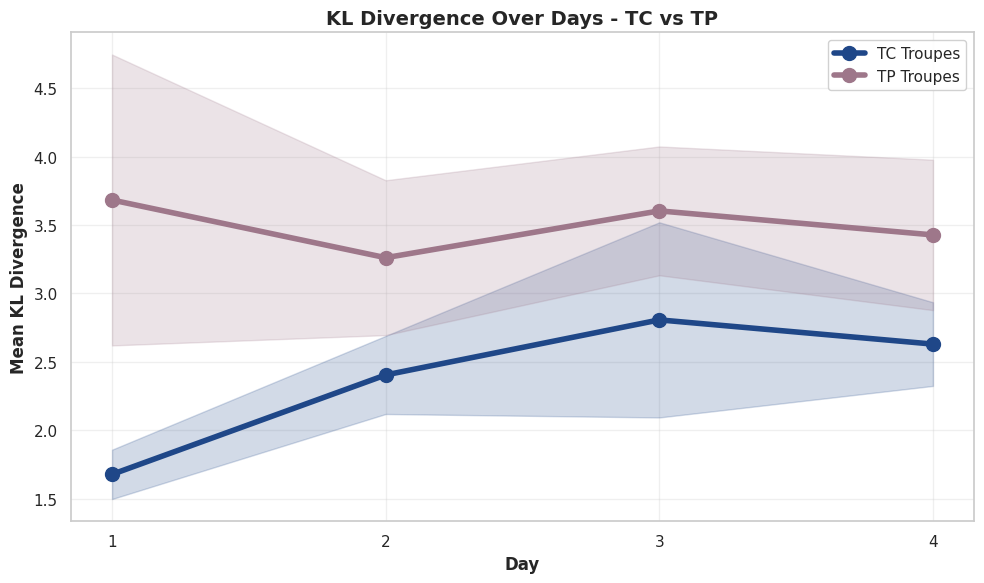


ANALYSIS COMPLETE

Dataframe summary:
  - Total videos: 32
  - Troupes: ['TC-6', 'TC-7', 'TP-3', 'TP-4']
  - Days: ['1', '2', '3', '4']
  - Runs (32): ['2025_10_14_10_25_19_trial_1_TC', '2025_10_14_10_35_03_trial_1_TC', '2025_10_14_10_47_52_trial_1_TP', '2025_10_14_11_00_58_trial_1_TP', '2025_10_14_14_13_15_trial_1_TC', '2025_10_14_14_25_09_trial_1_TC', '2025_10_14_14_35_32_trial_1_TP', '2025_10_14_14_49_36_trial_1_TP', '2025_10_15_10_09_28_trial_1_TC', '2025_10_15_10_20_58_trial_1_TC', '2025_10_15_10_37_01_trial_1_TP', '2025_10_15_10_52_34_trial_1_TP', '2025_10_15_14_16_21_trial_1_TC', '2025_10_15_14_30_16_trial_1_TC', '2025_10_15_14_43_14_trial_1_TP', '2025_10_15_14_57_00_trial_1_TP', '2025_10_16_09_59_15_trial_1_TC', '2025_10_16_10_10_37_trial_1_TC', '2025_10_16_10_24_06_trial_1_TP', '2025_10_16_10_37_16_trial_1_TP', '2025_10_16_14_12_17_trial_1_TC', '2025_10_16_14_28_16_trial_1_TC', '2025_10_16_14_48_01_trial_1_TP', '2025_10_16_15_00_56_trial_1_TP', '2025_10_17_10_05_03_trial_1_TC

In [54]:
# ============================================================================
# MASTER EXECUTION CELL - Configure and Run Complete Analysis
# ============================================================================

# ----------------------------------------------------------------------------
# CONFIGURATION - Modify these paths and parameters
# ----------------------------------------------------------------------------

# Input file paths
kl_csv_path = '/n/holylabs/gershman_lab/Users/zkelso/KL_divergence_results/Tasmanian_Conditioning_KL_Results_COMPILED_2026_03_25_14_36_31.csv'

log_csv_path = '/n/holylabs/gershman_lab/Users/zkelso/KL_divergence_results/utils/Planarian_Experiments_Log.csv'

# Output paths
updated_kl_csv_path = '/n/holylabs/gershman_lab/Users/zkelso/KL_divergence_results/kl_divergence_with_metadata.csv'
output_dir = '/n/holylabs/gershman_lab/Users/zkelso/KL_divergence_results/figures/'

# Analysis parameters
troupe_list = ['TC-6','TC-7','TP-3','TP-4']  # List of all valid troupes
save_figures = False  # Set to False to only display, not save
figure_format = 'svg'  # Options: 'png', 'pdf', 'svg'
figure_dpi = 300  # Resolution for saved figures
plot_null = True  # Set to False to hide null distribution on plots
plot_individual_lines = False




# ----------------------------------------------------------------------------
# EXECUTION - Run the complete pipeline
# ----------------------------------------------------------------------------

print("="*80)
print("STARTING KL DIVERGENCE ANALYSIS PIPELINE")
print("="*80)

# Step 1: Update KL CSV with experimental log information
print("\n[1/4] Updating KL CSV with experimental metadata...")
updated_kl_df = update_kl_with_log_info(
    kl_csv_path=kl_csv_path,
    log_csv_path=log_csv_path,
    output_csv_path=None      # This chunk is not in use, not saving this csv
)

# Step 2: Create worm-specific dataframe
print("\n[2/4] Creating worm-specific KL dataframe...")
worm_kl_df = create_worm_kl_dataframe_from_df(updated_kl_df)
print(f"Created dataframe with {len(worm_kl_df)} videos")
print(f"Columns: {list(worm_kl_df.columns)}")

# Step 3: Generate single plot for KL(CS On||Off)
# print("\n[3/4] Generating KL divergence plot across days...")
fig_onoff = plot_troupe_kl_over_days(
    worm_kl_df, 
    troupe_list, 
    plot_null=plot_null,
    figsize=(10, 6)
)

# Step 3: Generate single plot for KL(CS On||Off)
if plot_individual_lines:
    fig_onoff = plot_troupe_kl_over_days(
        worm_kl_df,
        troupe_list,
        plot_null=plot_null,
        figsize=(10, 6),
        plot_individual_lines=plot_individual_lines   # ← new
)

# Optional: Save the figure
save_figures = True
if save_figures:
    os.makedirs(output_dir, exist_ok=True)
    if plot_individual_lines:
        filename = f"kl_onoff_{'_'.join(troupe_list)}_individual_FINAL.{figure_format}"
    else:
        filename = f"kl_onoff_{'_'.join(troupe_list)}_FINAL.{figure_format}"
    filepath = os.path.join(output_dir, filename)
    fig_onoff.savefig(filepath, dpi=figure_dpi, bbox_inches='tight')
    print(f"Saved KL divergence across days plot to: {filepath}")

plt.show()

# ----------------------------------------------------------------------------
# SUMMARY
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print(f"\nDataframe summary:")
print(f"  - Total videos: {len(worm_kl_df)}")
print(f"  - Troupes: {sorted(worm_kl_df['Troupe'].unique())}")
print(f"  - Days: {sorted(worm_kl_df['Day'].unique())}")
print(f"  - Runs ({len(worm_kl_df['Run'].unique())}): {sorted(worm_kl_df['Run'].unique())}")

print(f"\nFiles created:")
print(f"  - Updated KL CSV: {updated_kl_csv_path}")
if save_figures:
    print(f"  - Figures saved to: {output_dir}")

print("\nPlot generation complete!")

# LMM 

In [ ]:
# # Original code showing individual KLs across days for worms, with population trend overlaid
# # Reshape the dataframe so it's clean. 
# print("Creating worm-specific KL dataframe...")
# worm_kl_df = create_dataframe_for_LMM(updated_kl_df)

# # 1. Identify your ID columns
# id_cols = ['Run', 'Troupe', 'Day', 'Block']

# # 2. Melt the dataframe so all "W" columns are in one long list
# df_melted = pd.melt(worm_kl_df, id_vars=id_cols, var_name='Full_Metric', value_name='Value')

# # 3. Split the 'Full_Metric' column (e.g., 'W5_Areas_KL') into 'Subject_ID' and 'Metric'
# # We split on the first underscore only
# df_split = df_melted['Full_Metric'].str.split('_', n=1, expand=True)
# df_melted['Subject_ID'] = df_split[0]
# df_melted['Metric'] = df_split[1]

# # 4. Pivot the table back so each metric (Areas_KL, etc.) is its own column
# df_long = df_melted.pivot_table(
#     index=id_cols + ['Subject_ID'], 
#     columns='Metric', 
#     values='Value',
#     aggfunc='first'
# ).reset_index()

# # 5. Clean Subject_ID to be an integer
# df_long['Subject_ID'] = df_long['Subject_ID'].str.replace('W', '').astype(int)

# # Convert columns to numeric, forcing errors to NaN (then dropping them if necessary)
# df_long['Day'] = pd.to_numeric(df_long['Day'], errors='coerce')
# df_long['KL'] = pd.to_numeric(df_long['KL'], errors='coerce')

# # Subject_ID is usually categorical, but ensuring it's at least a consistent 
# # string or integer prevents the DTypePromotionError
# df_long['Subject_ID'] = df_long['Subject_ID'].astype(str) 

# # Drop any rows that failed conversion
# df_long = df_long.dropna(subset=['Day', 'KL'])

# import matplotlib.pyplot as plt
# import seaborn as sns

# # 1. Set the visual style
# sns.set_theme(style="whitegrid")
# plt.figure(figsize=(10, 6))

# # 2. Draw individual subject trajectories
# # Using 'hue' creates a line for each Subject_ID
# sns.lineplot(
#     data=df_long, 
#     x="Day", 
#     y="KL", 
#     hue="Subject_ID", 
#     marker="o", 
#     palette="tab10", 
#     alpha=0.6
# )

# # 3. Add a thick regression line to show the overall population trend
# sns.regplot(
#     data=df_long, 
#     x="Day", 
#     y="KL", 
#     scatter=False, 
#     color="black", 
#     label="Overall Trend",
#     line_kws={"linewidth": 3, "linestyle": "--"}
# )

# plt.title("KL Value Progression: Individual Subject Trends", fontsize=14)
# plt.ylabel("KL Value")
# plt.xlabel("Day")
# plt.xticks([1, 2, 3, 4]) # Ensure only day integers show
# plt.legend(title="Subject ID", bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()


# Updated individual trends to show TC and TP separately, and then pooled
# Reshape the dataframe so it's clean. 
print("Creating worm-specific KL dataframe...")
worm_kl_df = create_dataframe_for_LMM(updated_kl_df)

# 1. Identify your ID columns
id_cols = ['Run', 'Troupe', 'Day', 'Block']

# 2. Melt the dataframe so all "W" columns are in one long list
df_melted = pd.melt(worm_kl_df, id_vars=id_cols, var_name='Full_Metric', value_name='Value')

# 3. Split the 'Full_Metric' column (e.g., 'W5_Areas_KL') into 'Subject_ID' and 'Metric'
# We split on the first underscore only
df_split = df_melted['Full_Metric'].str.split('_', n=1, expand=True)
df_melted['Subject_ID'] = df_split[0]
df_melted['Metric'] = df_split[1]

# 4. Pivot the table back so each metric (Areas_KL, etc.) is its own column
df_long = df_melted.pivot_table(
    index=id_cols + ['Subject_ID'], 
    columns='Metric', 
    values='Value',
    aggfunc='first'
).reset_index()

# 5. Clean Subject_ID to be an integer
df_long['Subject_ID'] = df_long['Subject_ID'].str.replace('W', '').astype(int)

# Convert columns to numeric, forcing errors to NaN (then dropping them if necessary)
df_long['Day'] = pd.to_numeric(df_long['Day'], errors='coerce')
df_long['KL'] = pd.to_numeric(df_long['KL'], errors='coerce')

# Subject_ID is usually categorical, but ensuring it's at least a consistent 
# string or integer prevents the DTypePromotionError
df_long['Subject_ID'] = df_long['Subject_ID'].astype(str) 

# Drop any rows that failed conversion
df_long = df_long.dropna(subset=['Day', 'KL'])

import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Create 3 subplots: TC, TP, and Pooled
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Define troupe groups and colors
troupe_groups = [
    ('TC', df_long['Troupe'].str.contains('TC'), '#1f4788'),  # Dark blue for TC
    ('TP', df_long['Troupe'].str.contains('TP'), '#9467bd'),  # Purple for TP
    ('All (Pooled)', pd.Series([True] * len(df_long), index=df_long.index), 'black')  # Black for pooled
]

for ax, (label, filter_mask, color) in zip(axes, troupe_groups):
    df_filtered = df_long[filter_mask].copy()
    
    # Draw individual subject trajectories
    sns.lineplot(
        data=df_filtered, 
        x="Day", 
        y="KL", 
        hue="Subject_ID", 
        marker="o", 
        palette="tab10", 
        alpha=0.5,
        ax=ax,
        legend=False  # Hide legend for cleaner look
    )
    
    # Add a thick regression line to show the overall population trend
    sns.regplot(
        data=df_filtered, 
        x="Day", 
        y="KL", 
        scatter=False, 
        color=color, 
        label=f"{label} Trend",
        line_kws={"linewidth": 3, "linestyle": "--"},
        ax=ax
    )
    
    # Formatting
    ax.set_title(f"{label} - KL Value Progression", fontsize=13, fontweight='bold')
    ax.set_ylabel("KL Value", fontsize=11)
    ax.set_xlabel("Day", fontsize=11)
    ax.set_xticks([1, 2, 3, 4])
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Individual Subject Trends: TC vs TP vs Pooled", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# --- 2. Fit the Log-Transformed Trend Model ---
# This is likely your most accurate model

df_long['log_KL'] = np.log(df_long['KL'])

model_log = smf.mixedlm("log_KL ~ Day", df_long, groups=df_long["Subject_ID"])
result_log = model_log.fit()
print("--- Log-Transformed Model Summary ---")
print(result_log.summary())

# --- 3. Visualization: Trend & Diagnostics ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot A: The Log-Trend (Publication Style)
sns.lineplot(
    data=df_long, x="Day", y="log_KL", hue="Subject_ID", 
    marker="o", palette="viridis", alpha=0.4, ax=axes[0]
)
sns.regplot(
    data=df_long, x="Day", y="log_KL", scatter=False, 
    color="black", line_kws={"linewidth": 3, "ls": "--"}, ax=axes[0]
)
axes[0].set_title("Upward Trend (Log-Scale)", fontsize=14)
axes[0].set_ylabel("log(KL Divergence)")
axes[0].set_xticks([1, 2, 3, 4])

# Plot B: Q-Q Plot (The "Check" for Normality)
# We use the residuals from the log model
stats.probplot(result_log.resid, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot: Normality of Residuals", fontsize=14)

plt.tight_layout()
plt.show()

NameError: name 'smf' is not defined

In [11]:
import statsmodels.formula.api as smf
import scipy.stats as stats


# 1. Fit the Full Model (with Day)
# Use 'REML=False' because we are comparing models with different fixed effects
#model_full = smf.mixedlm("KL ~ C(Day)", df_long, groups=df_long["Subject_ID"])
model_full = smf.mixedlm("np.log(KL) ~ C(Day)", df_long, groups=df_long["Subject_ID"])

#model_full = smf.mixedlm("KL ~ Day", df_long, groups=df_long["Subject_ID"])
result_full = model_full.fit(reml=False)
print(result_full.summary())

# 2. Fit the Null Model (without Day)
model_null = smf.mixedlm("KL ~ 1", df_long, groups=df_long["Subject_ID"])
result_null = model_null.fit(reml=False)

# 3. Perform Likelihood Ratio Test
lr_stat = 2 * (result_full.llf - result_null.llf)
# Calculate the difference in the number of parameters
df_diff = len(result_full.params) - len(result_null.params)

# If df_diff is 0 for some reason (rare), the test isn't valid
if df_diff > 0:
    p_value = stats.chi2.sf(lr_stat, df_diff)
    print(f"Likelihood Ratio Statistic: {lr_stat:.4f}")
    print(f"Degrees of Freedom: {df_diff}")
    print(f"p-value: {p_value:.4f}") # Using scientific notation for small p-values
else:
    print("Error: Models have the same number of parameters. Check your formula.")
    
if p_value > 0.05:
    print("Day is not a significant predictor of KL")

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: np.log(KL)
No. Observations: 192     Method:             ML        
No. Groups:       6       Scale:              0.4829    
Min. group size:  32      Log-Likelihood:     -202.5845 
Max. group size:  32      Converged:          No        
Mean group size:  32.0                                  
--------------------------------------------------------
                Coef. Std.Err.   z   P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept       0.697    0.100 6.937 0.000  0.500  0.893
C(Day)[T.2]     0.088    0.142 0.623 0.533 -0.190  0.366
C(Day)[T.3]     0.239    0.142 1.686 0.092 -0.039  0.517
C(Day)[T.4]     0.223    0.142 1.574 0.115 -0.055  0.501
Group Var       0.000                                   

Likelihood Ratio Statistic: 458.6810
Degrees of Freedom: 3
p-value: 0.0000


/n/home02/zkelso/.conda/envs/SAM/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/n/home02/zkelso/.conda/envs/SAM/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/n/home02/zkelso/.conda/envs/SAM/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/n/home02/zkelso/.conda/envs/SAM/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/n/home02/zkelso/.conda/envs/SAM/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood o

## Updated bits to show PC-TC difference

In [ ]:
# Visualization of log KL divergence separating TC and TP, with Q-Q plots 

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Define colors and troupe groups
tc_color = '#1f4788'
tp_color = '#9467bd'

for idx, (troupe_type, color, troupe_filter) in enumerate([
    ('TC', tc_color, df_long['Troupe'].str.contains('TC')),
    ('TP', tp_color, df_long['Troupe'].str.contains('TP'))
]):
    df_filtered = df_long[troupe_filter].copy()
    df_filtered['log_KL'] = np.log(df_filtered['KL'])
    
    # Plot A: The Log-Trend
    sns.lineplot(
        data=df_filtered, x="Day", y="log_KL", hue="Subject_ID", 
        marker="o", palette="viridis", alpha=0.4, ax=axes[0, idx]
    )
    sns.regplot(
        data=df_filtered, x="Day", y="log_KL", scatter=False, 
        color=color, line_kws={"linewidth": 3, "ls": "--"}, ax=axes[0, idx]
    )
    axes[0, idx].set_title(f"{troupe_type} Troupes: Upward Trend (Log-Scale)", fontsize=14)
    axes[0, idx].set_ylabel("log(KL Divergence)")
    axes[0, idx].set_xticks([1, 2, 3, 4])
    
    # Plot B: Q-Q Plot
    model_log = smf.mixedlm("log_KL ~ Day", df_filtered, groups=df_filtered["Subject_ID"])
    result_log = model_log.fit()
    stats.probplot(result_log.resid, dist="norm", plot=axes[1, idx])
    axes[1, idx].set_title(f"{troupe_type} Troupes: Q-Q Plot", fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
for troupe_type, troupe_filter in [('TC', df_long['Troupe'].str.contains('TC')), 
                                     ('TP', df_long['Troupe'].str.contains('TP'))]:
    print(f"\n{'='*60}")
    print(f"ANALYSIS FOR {troupe_type} TROUPES")
    print(f"{'='*60}")
    
    df_filtered = df_long[troupe_filter].copy()
    
    # 1. Fit the Full Model (with Day)
    model_full = smf.mixedlm("np.log(KL) ~ C(Day)", df_filtered, groups=df_filtered["Subject_ID"])
    result_full = model_full.fit(reml=False)
    print(result_full.summary())
    
    # 2. Fit the Null Model (without Day)
    model_null = smf.mixedlm("KL ~ 1", df_filtered, groups=df_filtered["Subject_ID"])
    result_null = model_null.fit(reml=False)
    
    # 3. Perform Likelihood Ratio Test
    lr_stat = 2 * (result_full.llf - result_null.llf)
    df_diff = len(result_full.params) - len(result_null.params)
    
    if df_diff > 0:
        p_value = stats.chi2.sf(lr_stat, df_diff)
        print(f"Likelihood Ratio Statistic: {lr_stat:.4f}")
        print(f"Degrees of Freedom: {df_diff}")
        print(f"p-value: {p_value:.4f}")
    
    if p_value > 0.05:
        print(f"Day is not a significant predictor of KL for {troupe_type}")
    else:
        print(f"Day IS a significant predictor of KL for {troupe_type}")